In [ ]:
print("Merhaba trader!")

Merhaba trader!


In [ ]:
import requests
import pandas as pd

# Adım 1: Timestamp listesini çek
url_index = "https://www.smard.de/app/chart_data/4169/DE/index_hour.json"
r = requests.get(url_index)
timestamps = r.json()["timestamps"]

# Adım 2: En son timestamp'i seç (en güncel veri)
latest_ts = max(timestamps)
print(f"En güncel timestamp: {latest_ts}")

# Adım 3: O timestamp'in verisini çek
url_data = f"https://www.smard.de/app/chart_data/4169/DE/4169_DE_hour_{latest_ts}.json"
r2 = requests.get(url_data)
series = r2.json()["series"]

# Adım 4: Pandas DataFrame'e çevir
df = pd.DataFrame(series, columns=["timestamp_ms", "price_eur_mwh"])
df["datetime"] = pd.to_datetime(df["timestamp_ms"], unit="ms")
df = df.dropna(subset=["price_eur_mwh"])  # null'ları çıkar
df = df[["datetime", "price_eur_mwh"]]

print(df.head(10))
print(f"\nToplam satır: {len(df)}")
print(f"Min fiyat: {df['price_eur_mwh'].min():.2f} €/MWh")
print(f"Max fiyat: {df['price_eur_mwh'].max():.2f} €/MWh")
print(f"Negatif fiyat saati: {(df['price_eur_mwh'] < 0).sum()}")

En güncel timestamp: 1775426400000
             datetime  price_eur_mwh
0 2026-04-05 22:00:00           3.24
1 2026-04-05 23:00:00           1.99
2 2026-04-06 00:00:00           1.04
3 2026-04-06 01:00:00           1.36
4 2026-04-06 02:00:00           1.06
5 2026-04-06 03:00:00           2.11
6 2026-04-06 04:00:00           1.99
7 2026-04-06 05:00:00           1.33
8 2026-04-06 06:00:00          -0.94
9 2026-04-06 07:00:00         -11.10

Toplam satır: 72
Min fiyat: -125.64 €/MWh
Max fiyat: 194.03 €/MWh
Negatif fiyat saati: 20


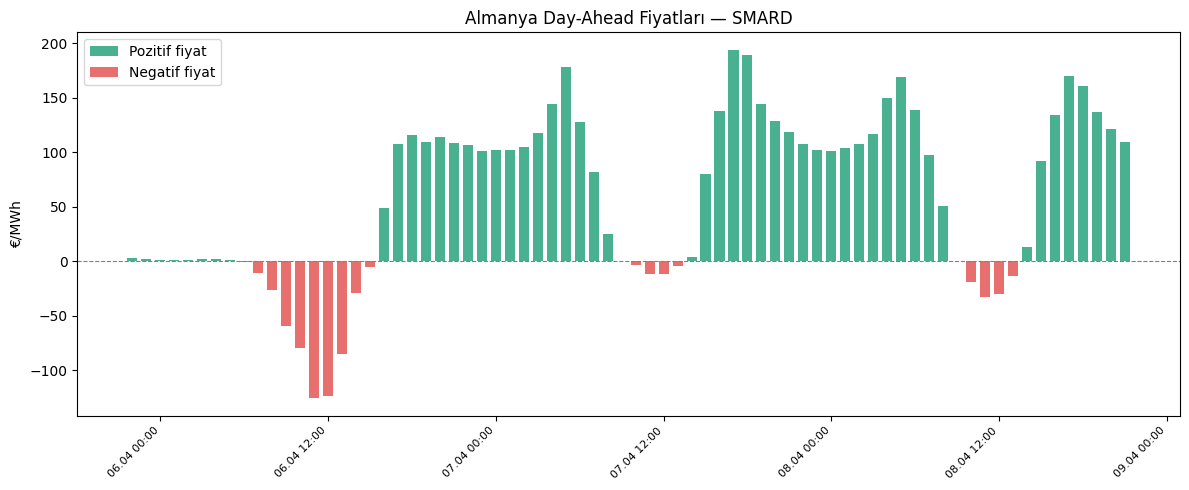

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 5))

# Pozitif ve negatif fiyatları farklı renkte göster
pozitif = df[df["price_eur_mwh"] >= 0]
negatif = df[df["price_eur_mwh"] < 0]

ax.bar(pozitif["datetime"], pozitif["price_eur_mwh"],
       width=0.03, color="#1D9E75", alpha=0.8, label="Pozitif fiyat")
ax.bar(negatif["datetime"], negatif["price_eur_mwh"],
       width=0.03, color="#E24B4A", alpha=0.8, label="Negatif fiyat")

ax.axhline(y=0, color="gray", linewidth=0.8, linestyle="--")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m %H:%M"))
plt.xticks(rotation=45, ha="right", fontsize=8)
ax.set_ylabel("€/MWh")
ax.set_title("Almanya Day-Ahead Fiyatları — SMARD")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Basit peak/off-peak strateji analizi
# Off-peak: 00:00 - 06:00 arası saatler
# Peak:     10:00 - 20:00 arası saatler

df["hour"] = df["datetime"].dt.hour

off_peak = df[df["hour"].between(0, 6)]["price_eur_mwh"].mean()
peak     = df[df["hour"].between(10, 20)]["price_eur_mwh"].mean()
spread   = peak - off_peak

print(f"Off-peak ortalama : {off_peak:.2f} €/MWh")
print(f"Peak ortalama     : {peak:.2f} €/MWh")
print(f"Spread (fark)     : {spread:.2f} €/MWh")
print(f"\nBir trader yorumu:")
print(f"→ 1 MWh alıp satsan teorik kazanç: {spread:.2f} €")
print(f"→ 100 MWh pozisyon için: {spread*100:.0f} €")

Off-peak ortalama : 84.32 €/MWh
Peak ortalama     : 49.38 €/MWh
Spread (fark)     : -34.94 €/MWh

Bir trader yorumu:
→ 1 MWh alıp satsan teorik kazanç: -34.94 €
→ 100 MWh pozisyon için: -3494 €


In [ ]:
url_index = "https://www.smard.de/app/chart_data/4169/DE/index_hour.json"
timestamps = requests.get(url_index).json()["timestamps"]

# İlk ve son timestamp'i insan dilinde göster
ilk = pd.to_datetime(timestamps[0], unit="ms")
son = pd.to_datetime(timestamps[-1], unit="ms")
ikinci = pd.to_datetime(timestamps[1], unit="ms")

print(f"Toplam blok sayısı : {len(timestamps)}")
print(f"İlk blok tarihi    : {ilk}")
print(f"İkinci blok tarihi : {ikinci}")
print(f"Bloklar arası fark : {ikinci - ilk}")
print(f"Son blok tarihi    : {son}")


Toplam blok sayısı : 393
İlk blok tarihi    : 2018-09-30 22:00:00
İkinci blok tarihi : 2018-10-07 22:00:00
Bloklar arası fark : 7 days 00:00:00
Son blok tarihi    : 2026-04-05 22:00:00


In [ ]:
son_1_yil = timestamps[-52:]

tum_seriler = []
for i, ts in enumerate(son_1_yil):
    url = f"https://www.smard.de/app/chart_data/4169/DE/4169_DE_hour_{ts}.json"
    r = requests.get(url)
    tum_seriler.extend(r.json()["series"])
    time.sleep(0.3)
    if i % 10 == 0:
        print(f"{i+1}/52 blok çekildi...")

df_yil = pd.DataFrame(tum_seriler, columns=["timestamp_ms", "price_eur_mwh"])
df_yil["datetime"] = pd.to_datetime(df_yil["timestamp_ms"], unit="ms")
df_yil = df_yil.dropna(subset=["price_eur_mwh"])
df_yil["hour"] = df_yil["datetime"].dt.hour
df_yil["month"] = df_yil["datetime"].dt.month

print(f"\nToplam saat: {len(df_yil)}")
print(f"Negatif fiyat saati: {(df_yil['price_eur_mwh'] < 0).sum()}")
print(f"Negatif fiyat oranı: %{(df_yil['price_eur_mwh'] < 0).mean()*100:.1f}")

NameError: name 'time' is not defined

In [ ]:
import time  # ← bunu ekle

son_1_yil = timestamps[-52:]

tum_seriler = []
for i, ts in enumerate(son_1_yil):
    url = f"https://www.smard.de/app/chart_data/4169/DE/4169_DE_hour_{ts}.json"
    r = requests.get(url)
    tum_seriler.extend(r.json()["series"])
    time.sleep(0.3)
    if i % 10 == 0:
        print(f"{i+1}/52 blok çekildi...")

df_yil = pd.DataFrame(tum_seriler, columns=["timestamp_ms", "price_eur_mwh"])
df_yil["datetime"] = pd.to_datetime(df_yil["timestamp_ms"], unit="ms")
df_yil = df_yil.dropna(subset=["price_eur_mwh"])
df_yil["hour"] = df_yil["datetime"].dt.hour
df_yil["month"] = df_yil["datetime"].dt.month

print(f"\nToplam saat: {len(df_yil)}")
print(f"Negatif fiyat saati: {(df_yil['price_eur_mwh'] < 0).sum()}")
print(f"Negatif fiyat oranı: %{(df_yil['price_eur_mwh'] < 0).mean()*100:.1f}")

1/52 blok çekildi...
11/52 blok çekildi...
21/52 blok çekildi...
31/52 blok çekildi...
41/52 blok çekildi...
51/52 blok çekildi...

Toplam saat: 8640
Negatif fiyat saati: 572
Negatif fiyat oranı: %6.6


In [ ]:
ay_isimleri = {1:"Oca",2:"Şub",3:"Mar",4:"Nis",5:"May",6:"Haz",
               7:"Tem",8:"Ağu",9:"Eyl",10:"Eki",11:"Kas",12:"Ara"}

aylik = df_yil.groupby("month").agg(
    toplam_saat  = ("price_eur_mwh", "count"),
    negatif_saat = ("price_eur_mwh", lambda x: (x < 0).sum()),
    ort_fiyat    = ("price_eur_mwh", "mean"),
    min_fiyat    = ("price_eur_mwh", "min"),
).reset_index()

aylik["negatif_oran_%"] = (aylik["negatif_saat"] / aylik["toplam_saat"] * 100).round(1)
aylik["ay"] = aylik["month"].map(ay_isimleri)

print(aylik[["ay","negatif_saat","negatif_oran_%","ort_fiyat","min_fiyat"]].to_string(index=False))

 ay  negatif_saat  negatif_oran_%  ort_fiyat  min_fiyat
Oca             2             0.3 110.142097      -0.01
Şub             7             1.0  96.505060      -0.25
Mar            33             4.4  99.460484     -11.76
Nis            76            12.7  76.658383    -129.81
May           129            17.3  67.323118    -250.32
Haz           141            19.6  64.027528     -99.01
Tem            12             1.6  87.791573      -2.26
Ağu            64             8.6  76.938723     -61.08
Eyl            60             8.3  83.528236     -53.40
Eki            48             6.5  84.350591      -4.98
Kas             0             0.0 101.928556       4.93
Ara             0             0.0  93.430296       3.51


In [ ]:
saatlik = df_yil.groupby("hour").agg(
    ort_fiyat    = ("price_eur_mwh", "mean"),
    negatif_oran = ("price_eur_mwh", lambda x: (x < 0).mean() * 100),
    min_fiyat    = ("price_eur_mwh", "min"),
    max_fiyat    = ("price_eur_mwh", "max"),
).round(1)

print(saatlik.to_string())

      ort_fiyat  negatif_oran  min_fiyat  max_fiyat
hour                                               
0          80.5           1.1       -4.2      138.3
1          78.8           1.1       -4.4      136.1
2          79.3           1.7       -5.0      137.5
3          83.2           1.4       -4.5      149.1
4          93.0           0.8       -3.8      182.4
5         102.6           0.8       -1.5      300.0
6         103.3           1.1       -2.4      291.0
7          91.2           3.9      -11.1      333.3
8          74.4           9.7      -40.0      292.6
9          61.0          17.8      -71.3      273.1
10         50.7          22.8     -212.8      326.6
11         44.3          27.2     -250.3      351.0
12         45.4          27.2     -231.0      317.6
13         55.2          22.5     -110.1      300.0
14         70.3          13.3      -38.9      310.0
15         94.1           3.1      -16.7      325.1
16        119.9           0.8       -1.0      405.0
17        13

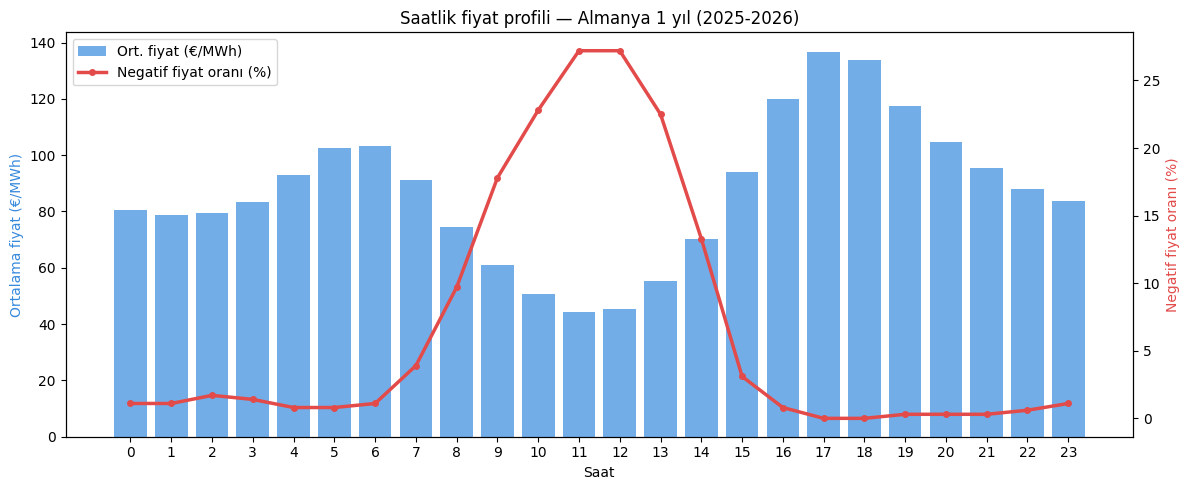

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(saatlik.index, saatlik["ort_fiyat"],
        color="#378ADD", alpha=0.7, label="Ort. fiyat (€/MWh)")
ax1.set_ylabel("Ortalama fiyat (€/MWh)", color="#378ADD")
ax1.set_xlabel("Saat")

ax2 = ax1.twinx()
ax2.plot(saatlik.index, saatlik["negatif_oran"],
         color="#E24B4A", linewidth=2.5, marker="o",
         markersize=4, label="Negatif fiyat oranı (%)")
ax2.set_ylabel("Negatif fiyat oranı (%)", color="#E24B4A")

ax1.set_xticks(range(24))
ax1.set_title("Saatlik fiyat profili — Almanya 1 yıl (2025-2026)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

In [ ]:
def veri_cek(filter_no, sutun_adi):
    """Verilen filter için 1 yıllık veri çeker"""
    # Timestamp listesini al
    url_index = f"https://www.smard.de/app/chart_data/{filter_no}/DE/index_hour.json"
    timestamps = requests.get(url_index).json()["timestamps"]
    son_1_yil = timestamps[-52:]

    # Tüm blokları çek
    seriler = []
    for i, ts in enumerate(son_1_yil):
        url = f"https://www.smard.de/app/chart_data/{filter_no}/DE/{filter_no}_DE_hour_{ts}.json"
        r = requests.get(url)
        seriler.extend(r.json()["series"])
        time.sleep(0.3)
        if i % 10 == 0:
            print(f"  {sutun_adi}: {i+1}/52 blok çekildi...")

    # DataFrame yap
    df = pd.DataFrame(seriler, columns=["timestamp_ms", sutun_adi])
    df["datetime"] = pd.to_datetime(df["timestamp_ms"], unit="ms")
    return df[["datetime", sutun_adi]]

# Üç veriyi çek
print("Fiyat çekiliyor...")
df_fiyat  = veri_cek(4169, "price_eur_mwh")

print("Rüzgar çekiliyor...")
df_ruzgar = veri_cek(4067, "wind_mwh")

print("Güneş çekiliyor...")
df_gunes  = veri_cek(4068, "solar_mwh")

# Birleştir
df_birlesik = df_fiyat.merge(df_ruzgar, on="datetime").merge(df_gunes, on="datetime")
df_birlesik = df_birlesik.dropna()

print(f"\nBirleşik veri: {len(df_birlesik)} satır")
print(df_birlesik.head())

Fiyat çekiliyor...
  price_eur_mwh: 1/52 blok çekildi...
  price_eur_mwh: 11/52 blok çekildi...
  price_eur_mwh: 21/52 blok çekildi...
  price_eur_mwh: 31/52 blok çekildi...
  price_eur_mwh: 41/52 blok çekildi...
  price_eur_mwh: 51/52 blok çekildi...
Rüzgar çekiliyor...
  wind_mwh: 1/52 blok çekildi...
  wind_mwh: 11/52 blok çekildi...
  wind_mwh: 21/52 blok çekildi...
  wind_mwh: 31/52 blok çekildi...
  wind_mwh: 41/52 blok çekildi...
  wind_mwh: 51/52 blok çekildi...
Güneş çekiliyor...
  solar_mwh: 1/52 blok çekildi...
  solar_mwh: 11/52 blok çekildi...
  solar_mwh: 21/52 blok çekildi...
  solar_mwh: 31/52 blok çekildi...
  solar_mwh: 41/52 blok çekildi...
  solar_mwh: 51/52 blok çekildi...

Birleşik veri: 8612 satır
             datetime  price_eur_mwh  wind_mwh  solar_mwh
0 2025-04-13 22:00:00          87.56   4639.25      10.50
1 2025-04-13 23:00:00          82.69   3797.50       6.75
2 2025-04-14 00:00:00          82.11   3504.75       5.25
3 2025-04-14 01:00:00          82.29  

In [ ]:
# Korelasyon matrisi
korelasyon = df_birlesik[["price_eur_mwh", "wind_mwh", "solar_mwh"]].corr()
print(korelasyon.round(2))

               price_eur_mwh  wind_mwh  solar_mwh
price_eur_mwh           1.00     -0.30      -0.55
wind_mwh               -0.30      1.00      -0.26
solar_mwh              -0.55     -0.26       1.00


In [ ]:
# En düşük 10 fiyat saatinde rüzgar ve güneş ne durumdaydı?
en_dusuk = df_birlesik.nsmallest(10, "price_eur_mwh")
print(en_dusuk[["datetime", "price_eur_mwh", "wind_mwh", "solar_mwh"]].to_string(index=False))

           datetime  price_eur_mwh  wind_mwh  solar_mwh
2025-05-11 11:00:00        -250.32   1793.00   44042.25
2025-05-11 12:00:00        -230.98   1899.00   41823.00
2025-05-11 10:00:00        -212.82   1843.50   44887.25
2025-05-01 11:00:00        -129.99    689.25   44333.25
2025-04-27 11:00:00        -129.81   1287.50   42529.75
2026-04-06 11:00:00        -125.64   4174.94   39260.14
2026-04-06 12:00:00        -123.54   3883.31   37436.17
2025-05-01 12:00:00        -118.11    719.00   41661.75
2025-04-27 12:00:00        -116.61   1098.25   40607.25
2025-05-10 11:00:00        -114.53   1046.25   43269.25


In [34]:
# Tüketim satırını sen yaz:
df_tuketim = veri_cek(410, "consumption_mwh" )

# Birleştir — 4 veriyi tek tabloya
df_tam = df_birlesik.merge(df_tuketim, on="datetime")
df_tam = df_tam.dropna()

# Net fazla hesapla
df_tam["net_fazla_mwh"] = df_tam["wind_mwh"] + df_tam["solar_mwh"] - df_tam["consumption_mwh"]

# Yeni korelasyon
korelasyon2 = df_tam[["price_eur_mwh", "wind_mwh", "solar_mwh", "consumption_mwh", "net_fazla_mwh"]].corr()
print(korelasyon2["price_eur_mwh"].round(2))

  consumption_mwh: 1/52 blok çekildi...
  consumption_mwh: 11/52 blok çekildi...
  consumption_mwh: 21/52 blok çekildi...
  consumption_mwh: 31/52 blok çekildi...
  consumption_mwh: 41/52 blok çekildi...
  consumption_mwh: 51/52 blok çekildi...
price_eur_mwh      1.00
wind_mwh          -0.30
solar_mwh         -0.55
consumption_mwh    0.31
net_fazla_mwh     -0.86
Name: price_eur_mwh, dtype: float64


In [38]:
# Günlük alış-satış fiyatlarını bul
df_tam["date"] = df_tam["datetime"].dt.date

# Her gün saat 11 = alış, saat 17 = satış
alis  = df_tam[df_tam["datetime"].dt.hour == 11][["date", "price_eur_mwh"]].rename(columns={"price_eur_mwh": "alis_fiyat"})
satis = df_tam[df_tam["datetime"].dt.hour == 17][["date", "price_eur_mwh"]].rename(columns={"price_eur_mwh": "satis_fiyat"})

# Birleştir
strateji = alis.merge(satis, on="date")

# Günlük kazanç = satış - alış (1 MWh pozisyon)
strateji["gunluk_kazanc"] = strateji["satis_fiyat"] - strateji["alis_fiyat"]

# Kümülatif P&L
strateji["kumulatif_pnl"] = strateji["gunluk_kazanc"].cumsum()

# Sonuç
kazanan = (strateji["gunluk_kazanc"] > 0).sum()
kaybeden = (strateji["gunluk_kazanc"] < 0).sum()
toplam_pnl = strateji["gunluk_kazanc"].sum()

print(f"Toplam gün      : {len(strateji)}")
print(f"Kazanan gün     : {kazanan}")
print(f"Kaybeden gün    : {kaybeden}")
print(f"Kazanma oranı   : %{kazanan/len(strateji)*100:.1f}")
print(f"Toplam P&L      : {toplam_pnl:.2f} € / MWh")
print(f"Ortalama günlük : {strateji['gunluk_kazanc'].mean():.2f} € / MWh")
print(f"En iyi gün      : {strateji['gunluk_kazanc'].max():.2f} €")
print(f"En kötü gün     : {strateji['gunluk_kazanc'].min():.2f} €")

# Gerçekçi backtest — maliyetler dahil
komisyon = 0.5      # €/MWh işlem başına
min_spread = 10     # en az 10 € fark yoksa işlem yapma

strateji["gercek_kazanc"] = strateji["gunluk_kazanc"] - (2 * komisyon)

# Sadece yeterli spread varsa işlem yap
strateji["islem_var"] = strateji["gunluk_kazanc"].abs() > min_spread
strateji_filtreli = strateji[strateji["islem_var"]]

gercek_pnl = strateji_filtreli["gercek_kazanc"].sum()
gercek_kazanma = (strateji_filtreli["gercek_kazanc"] > 0).mean() * 100

print(f"İşlem yapılan gün : {len(strateji_filtreli)}")
print(f"Gerçekçi P&L      : {gercek_pnl:.2f} € / MWh")
print(f"Gerçekçi kazanma  : %{gercek_kazanma:.1f}")

Toplam gün      : 359
Kazanan gün     : 348
Kaybeden gün    : 11
Kazanma oranı   : %96.9
Toplam P&L      : 33120.82 € / MWh
Ortalama günlük : 92.26 € / MWh
En iyi gün      : 409.24 €
En kötü gün     : -53.09 €
İşlem yapılan gün : 342
Gerçekçi P&L      : 32736.68 € / MWh
Gerçekçi kazanma  : %98.8


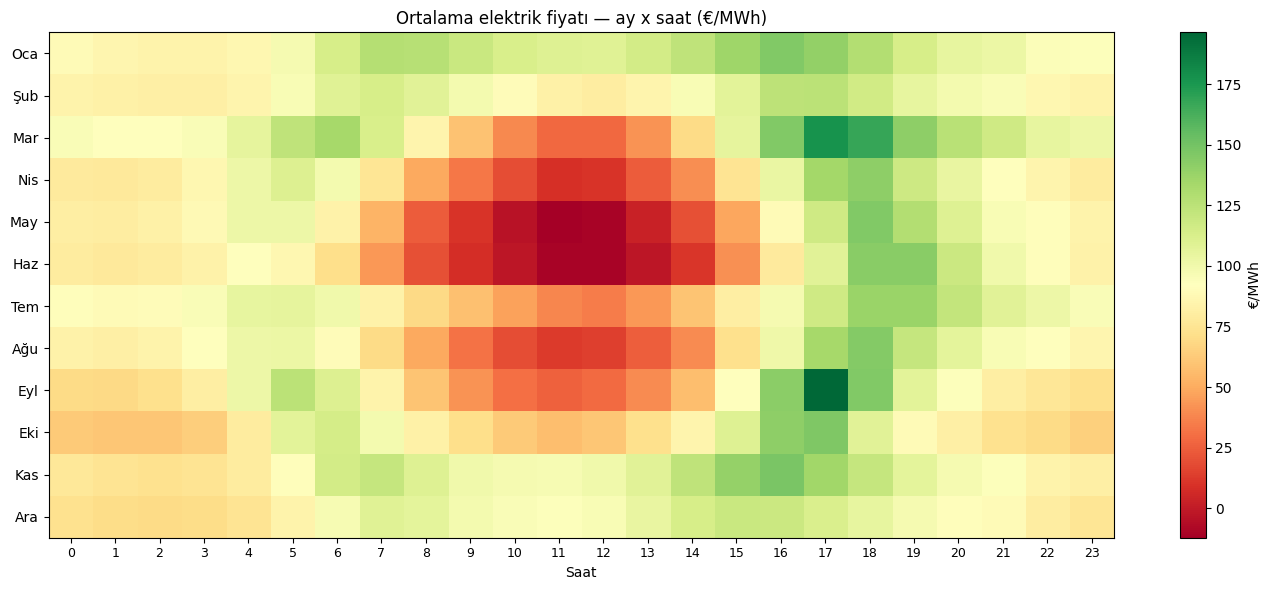

In [40]:
# Bu satırı en başa ekle
df_tam["month"] = df_tam["datetime"].dt.month

# Sonra heatmap kodu devam eder
pivot = df_tam.pivot_table(
    values="price_eur_mwh",
    index="month",
    columns=df_tam["datetime"].dt.hour,
    aggfunc="mean"
)

ay_isimleri = ["Oca","Şub","Mar","Nis","May","Haz",
               "Tem","Ağu","Eyl","Eki","Kas","Ara"]

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn")

ax.set_xticks(range(24))
ax.set_xticklabels(range(24), fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([ay_isimleri[m-1] for m in pivot.index])
ax.set_xlabel("Saat")
ax.set_title("Ortalama elektrik fiyatı — ay x saat (€/MWh)")

plt.colorbar(im, ax=ax, label="€/MWh")
plt.tight_layout()
plt.show()

In [42]:
df_tam["price_lag1"] = df_tam["price_eur_mwh"].shift(24)
# 24 saat önceki fiyat → dünün aynı saati
# Feature engineering
df_model = df_tam.copy()

# Lag features — geçmiş fiyatlar
df_model["price_lag24"]  = df_model["price_eur_mwh"].shift(24)   # dün aynı saat
df_model["price_lag48"]  = df_model["price_eur_mwh"].shift(48)   # önceki gün
df_model["price_lag168"] = df_model["price_eur_mwh"].shift(168)  # geçen hafta aynı saat

# Zaman özellikleri
df_model["hour"]      = df_model["datetime"].dt.hour
df_model["month"]     = df_model["datetime"].dt.month
df_model["dayofweek"] = df_model["datetime"].dt.dayofweek  # 0=Pazartesi, 6=Pazar

# Null'ları temizle (lag yüzünden ilk satırlar boş olur)
df_model = df_model.dropna()

print(f"Model verisi: {len(df_model)} satır")
print(df_model[["datetime","price_eur_mwh","price_lag24","hour","month"]].head())

Model verisi: 8444 satır
               datetime  price_eur_mwh  price_lag24  hour  month
168 2025-04-20 22:00:00         108.58       100.41    22      4
169 2025-04-20 23:00:00          97.59        94.90    23      4
170 2025-04-21 00:00:00          96.47        98.98     0      4
171 2025-04-21 01:00:00          96.84        97.41     1      4
172 2025-04-21 02:00:00          97.98        98.83     2      4


In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Girdi ve çıktı sütunlarını ayır
features = ["hour", "month", "dayofweek",
            "solar_mwh", "wind_mwh", "consumption_mwh",
            "net_fazla_mwh", "price_lag24", "price_lag48", "price_lag168"]

X = df_model[features]
y = df_model["price_eur_mwh"]

# %80 eğitim, %20 test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False)

# Modeli eğit
model = LinearRegression()
model.fit(X_train, y_train)

# Test seti üzerinde tahmin
y_pred = model.predict(X_test)

# Sonuçlar
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"Test seti sonuçları:")
print(f"MAE : {mae:.2f} €/MWh  ← ortalama hata")
print(f"R²  : {r2:.3f}         ← 1.0 = mükemmel, 0 = işe yaramaz")

Test seti sonuçları:
MAE : 19.05 €/MWh  ← ortalama hata
R²  : 0.764         ← 1.0 = mükemmel, 0 = işe yaramaz


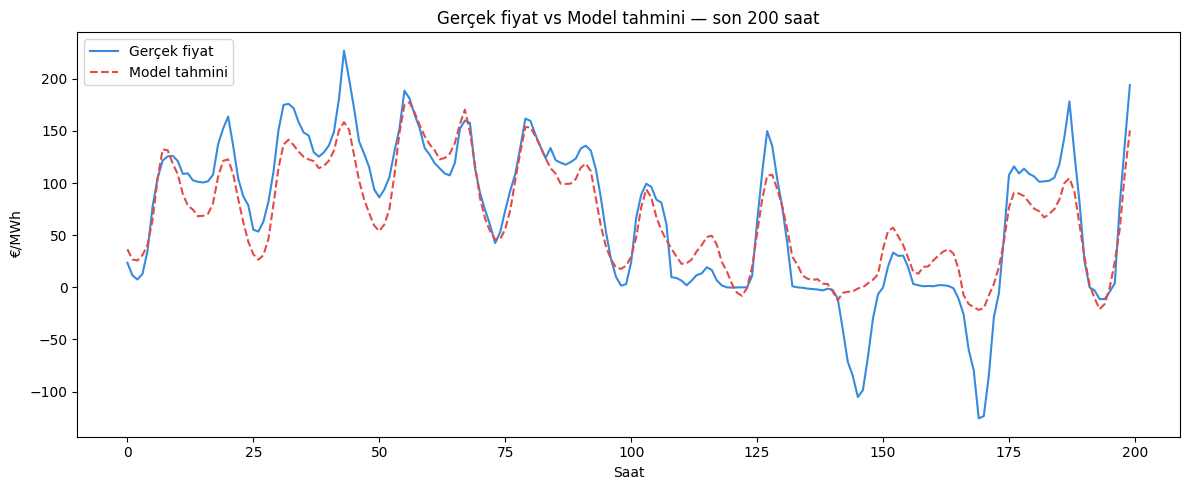

In [46]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

# Son 200 saati göster
n = 200
ax.plot(range(n), y_test.values[-n:],
        color="#378ADD", linewidth=1.5, label="Gerçek fiyat")
ax.plot(range(n), y_pred[-n:],
        color="#E24B4A", linewidth=1.5, linestyle="--", label="Model tahmini")

ax.set_xlabel("Saat")
ax.set_ylabel("€/MWh")
ax.set_title("Gerçek fiyat vs Model tahmini — son 200 saat")
ax.legend()
plt.tight_layout()
plt.show()


In [48]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest modeli
rf_model = RandomForestRegressor(
    n_estimators=100,    # 100 karar ağacı
    max_depth=10,        # ağaç derinliği
    random_state=42,
    n_jobs=-1            # tüm CPU'ları kullan
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf  = r2_score(y_test, y_pred_rf)

print(f"Linear Regression → MAE: 19.05  R²: 0.764")
print(f"Random Forest     → MAE: {mae_rf:.2f}  R²: {r2_rf:.3f}")
print(f"\nİyileşme: {19.05 - mae_rf:.2f} €/MWh daha az hata")

Linear Regression → MAE: 19.05  R²: 0.764
Random Forest     → MAE: 16.66  R²: 0.783

İyileşme: 2.39 €/MWh daha az hata


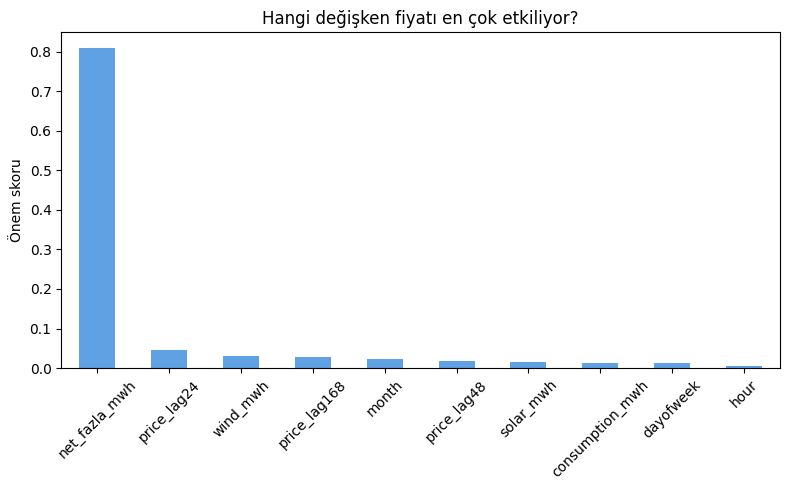

net_fazla_mwh      0.808465
price_lag24        0.046957
wind_mwh           0.029691
price_lag168       0.026949
month              0.023103
price_lag48        0.017973
solar_mwh          0.015944
consumption_mwh    0.012471
dayofweek          0.012354
hour               0.006096
dtype: float64


In [49]:
# Feature importance — hangi değişken en önemli?
importances = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="bar", ax=ax, color="#378ADD", alpha=0.8)
ax.set_title("Hangi değişken fiyatı en çok etkiliyor?")
ax.set_ylabel("Önem skoru")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(importances)